In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn 
import scipy 

In [2]:
df=pd.read_table('raw_data.csv', sep=',')

## Having an Overview of the data set

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
21137,95,CASH_OUT,56745.14,C526144262,56745.14,0.0,C79051264,51433.88,108179.02,1,0
21138,95,TRANSFER,33676.59,C732111322,33676.59,0.0,C1140210295,0.00,0.00,1,0
21139,95,CASH_OUT,33676.59,C1000086512,33676.59,0.0,C1759363094,0.00,33676.59,1,0
21140,95,TRANSFER,87999.25,C927181710,87999.25,0.0,C757947873,0.00,0.00,1,0
21141,95,CASH_OUT,87999.25,C409531429,87999.25,0.0,C1827219533,0.00,87999.25,1,0


In [5]:
df.dtypes

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

In [6]:
df.shape

(21142, 11)

## Checking Null Values

In [7]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [8]:
df.isnull().values.any()

False

In [9]:
print('Number of duplicates are : ', df.duplicated().sum())

Number of duplicates are :  0


In [10]:
df.drop_duplicates()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
21137,95,CASH_OUT,56745.14,C526144262,56745.14,0.00,C79051264,51433.88,108179.02,1,0
21138,95,TRANSFER,33676.59,C732111322,33676.59,0.00,C1140210295,0.00,0.00,1,0
21139,95,CASH_OUT,33676.59,C1000086512,33676.59,0.00,C1759363094,0.00,33676.59,1,0
21140,95,TRANSFER,87999.25,C927181710,87999.25,0.00,C757947873,0.00,0.00,1,0


In [11]:
#Now, let's rename some of the column names by using rename function.
df = df.rename(columns = {'nameOrig' : 'origin', 'oldbalanceOrg' : 'sender_old_balance', 'newbalanceOrig': 'sender_new_balance',
'nameDest' : 'destination', 'oldbalanceDest' : 'receiver_old_balance', 'newbalanceDest': 'receiver_new_balance',
'isFraud' : 'isfraud'})

In [12]:
#It's good to drop down the non essential columns from a dataset. We will do this with the help of drop function.
df = df.drop(columns = ['step', 'isFlaggedFraud'], axis = 'columns')

In [13]:
df.head()

,type,amount,origin,sender_old_balance,sender_new_balance,destination,receiver_old_balance,receiver_new_balance,isfraud
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0


## Filling In Missing Data

In [129]:
#fill nan values in type columns with the most frequent type of transaction
c=df['type'].value_counts()
df.fillna({0:c.index[0] })

,type,amount,origin,sender_old_balance,sender_new_balance,destination,receiver_old_balance,receiver_new_balance,isfraud
0,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0
1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0
2,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1
3,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1
4,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0
...,...,...,...,...,...,...,...,...,...
21137,CASH_OUT,56745.14,C526144262,56745.14,0.00,C79051264,51433.88,108179.02,1
21138,TRANSFER,33676.59,C732111322,33676.59,0.00,C1140210295,0.00,0.00,1
21139,CASH_OUT,33676.59,C1000086512,33676.59,0.00,C1759363094,0.00,33676.59,1
21140,TRANSFER,87999.25,C927181710,87999.25,0.00,C757947873,0.00,0.00,1


In [130]:
##fill nan values  in origin,destination columns with key value
#fill nan values  in (sender_old_balance,sender_new_balance,receiver_old_balance,receiver_new_balance)
#with mean value for each columns
df.fillna({2:"c00001111",3:df['sender_old_balance'].mean(),4:df['sender_new_balance'].mean() ,5:"m00001111",
6:df['receiver_old_balance'].mean(),7:df['receiver_new_balance'].mean()})

,type,amount,origin,sender_old_balance,sender_new_balance,destination,receiver_old_balance,receiver_new_balance,isfraud
0,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0
1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0
2,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1
3,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1
4,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0
...,...,...,...,...,...,...,...,...,...
21137,CASH_OUT,56745.14,C526144262,56745.14,0.00,C79051264,51433.88,108179.02,1
21138,TRANSFER,33676.59,C732111322,33676.59,0.00,C1140210295,0.00,0.00,1
21139,CASH_OUT,33676.59,C1000086512,33676.59,0.00,C1759363094,0.00,33676.59,1
21140,TRANSFER,87999.25,C927181710,87999.25,0.00,C757947873,0.00,0.00,1


In [131]:
df.head()

,type,amount,origin,sender_old_balance,sender_new_balance,destination,receiver_old_balance,receiver_new_balance,isfraud
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0


#### Types of fraudulent transacitons

In [132]:
#There are only 5 types of transactions occured, and only two of them can be a fraud. 1) 'TRANSFER' where money is sent to customer 2) 'CASH_OUT' where money is sent to merchant(customer)
list(df.loc[df.isfraud == 0].type.drop_duplicates().values)

['PAYMENT', 'DEBIT', 'CASH_OUT', 'TRANSFER', 'CASH_IN']

In [133]:
list(df.loc[df.isfraud == 1].type.drop_duplicates().values)

['TRANSFER', 'CASH_OUT']

## Data Visualization 

In [134]:
## Visualisation of transactions by type
valid = df[df['isfraud'] == 0]
fraud = df[df['isfraud'] == 1]

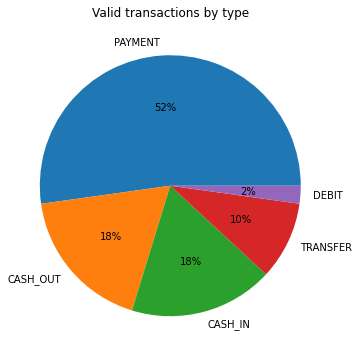

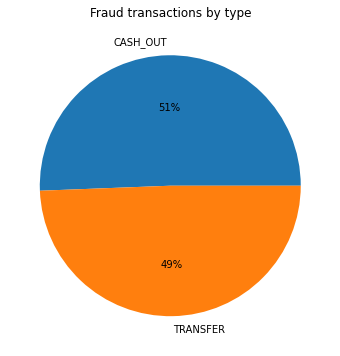

In [135]:

valid_type = valid['type'].value_counts()
valid_transaction = valid_type.index
valid_count = valid_type.values

fraud_type = fraud['type'].value_counts()
fraud_transaction = fraud_type.index
fraud_count = fraud_type.values

plt.figure(figsize=(10,6))
plt.pie(valid_count, labels= valid_transaction, autopct='%1.0f%%')
plt.title("Valid transactions by type")
plt.show()

plt.figure(figsize=(10,6))
plt.pie(fraud_count, labels= fraud_transaction, autopct='%1.0f%%')
plt.title("Fraud transactions by type")
plt.show()

### Insights
- There are 5 types of transactions found in valid transactions. Most common transaction type is CASH_OUT, followed by PAYMENT, CASH_IN, TRANSFER and DEBIT.
- Fraud transactions ONLY occur with CASH_OUT and TRANSFER equally at 50% each.
- 'type' is a necessary feature to keep to detect fraudulent transactions.

Text(0.5, 1.0, '% Fraud from TRANSFER and CASH_OUT type')

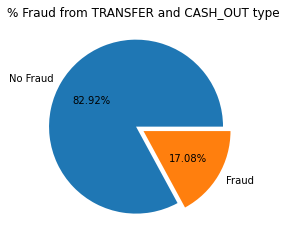

In [15]:
# % Fraud from TRANSFER and CASH_OUT type

df2= df[(df['type'].isin(['TRANSFER','CASH_OUT']))]
forpie = df2['isfraud'].value_counts()
label = ['No Fraud','Fraud']
plt.pie(forpie, labels = label , explode = (0.1, 0), autopct='%1.2f%%')   
plt.title('% Fraud from TRANSFER and CASH_OUT type')

### Exploring Amount of Transaction

Valid transactions by amount: 
 count    2.000000e+04
mean     1.241996e+05
std      2.728301e+05
min      2.390000e+00
25%      5.275458e+03
50%      1.591686e+04
75%      1.420273e+05
max      5.677662e+06
Name: amount, dtype: float64
 
 Fraud transactions by amount: 
 count    1.142000e+03
mean     1.192629e+06
std      2.030599e+06
min      1.190000e+02
25%      8.607017e+04
50%      3.531794e+05
75%      1.248759e+06
max      1.000000e+07
Name: amount, dtype: float64


Text(0.5, 1.0, 'Valid and Fraud Transaction Amounts')

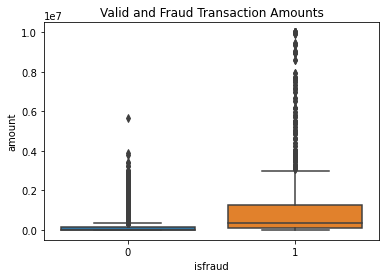

In [137]:
# View summary statistic of valid and fraud transaction amounts
print("Valid transactions by amount: \n", valid['amount'].describe())
print(" \n Fraud transactions by amount: \n", fraud['amount'].describe())

# Visualise summary statistics with boxplot
sns.boxplot(x = 'isfraud', y = 'amount', data = df)
plt.title('Valid and Fraud Transaction Amounts')

### Insights
- Average transaction amount is higher in fraud transactions than in valid transactions
- Fraud transactions are capped at 10,000,000 units currency whereas there appears to be no cap for valid transactions.
- 'amount' is a necessary feature to keep to detect fraudulent transactions.

- Now let's look at the relationship between data properties with the "isFraud" column:

In [113]:
correlation = df.corr()
print(correlation["isfraud"].sort_values(ascending=False))

isfraud                 1.000000
amount                  0.407498
sender_old_balance      0.041199
receiver_new_balance   -0.007342
receiver_old_balance   -0.034014
sender_new_balance     -0.081721
Name: isfraud, dtype: float64


- Let us now convert categorical characteristics into numerical properties. Here I will also convert the values ​​of the isFraud column into No Fraud and Fraud labels to get a better understanding of the output:

In [84]:
df["type"] = df["type"].map({"CASH_OUT": 1 , "PAYMENT":  2 , 
                                 "CASH_IN": 3 , "TRANSFER":  4 ,
                                 "DEBIT": 5 })
df["isfraud"] = df["isfraud"].map({0: "No Fraud", 1: "Fraud"})
print(df.head())

   step  type    amount       origin  sender_old_balance  sender_new_balance  \
0     1     2   9839.64  C1231006815            170136.0           160296.36   
1     1     2   1864.28  C1666544295             21249.0            19384.72   
2     1     4    181.00  C1305486145               181.0                0.00   
3     1     1    181.00   C840083671               181.0                0.00   
4     1     2  11668.14  C2048537720             41554.0            29885.86   

   destination  receiver_old_balance  receiver_new_balance   isfraud  \
0  M1979787155                   0.0                   0.0  No Fraud   
1  M2044282225                   0.0                   0.0  No Fraud   
2   C553264065                   0.0                   0.0     Fraud   
3    C38997010               21182.0                   0.0     Fraud   
4  M1230701703                   0.0                   0.0  No Fraud   

   isFlaggedFraud  
0               0  
1               0  
2               0  
3     

# Online payments fraud detection model



- Now let's train a classification model to classify fraudulent and non-fraudulent transactions.

- Before training the model, let's divide the data into training and test sets:

In [85]:
# Split data

from sklearn.model_selection import train_test_split
x = np.array(df[["type", "amount", "sender_old_balance", "sender_new_balance"]])
y = np.array(df[["isfraud"]])

In [86]:
#Now let's train the model:
from sklearn.tree import DecisionTreeClassifier
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.10, random_state=42)
model = DecisionTreeClassifier()
model.fit(xtrain, ytrain)

DecisionTreeClassifier()

In [87]:
print(model.score(xtest, ytest))

0.9947990543735225


- Let us now classify whether the transaction is fraudulent or not by entering a transaction in the model

In [88]:
# prediction
#features = [type, amount, oldbalanceOrg, newbalanceOrig] 

features = np.array([[4, 9839.64, 9839.64,0.0]])
print(model.predict(features))

['Fraud']
